# Libraries

In [1]:
## Standard libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import time
import copy
import argparse
import torch
import gc
import sys
from pathlib import Path
from tqdm import tqdm

# path to the directory that CONTAINS the package folder
project_root = Path("/home/benedetti/PL")   # adjust to your real path

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from PL.model.model import TwoBodiesModel
from PL.dataset.random_features import RandomDatasetPowerLaw, GeneralDataset
from PL.utils.saving import init_training_h5, save_training, load_training
from PL.utils.functions import start_overlap, compute_asymmetry, overlap, basins_of_attraction_inp_vectors

from PL.training.training_RF import train_model, initialize

device = torch.device("cuda:0")

data_PATH = "./data"


# PL

## Many trainings

In [2]:
exponent = 0.75

# Step
n = 100
d=1
eta=None
alpha_D = 0.1

In [3]:
# Model and training
l=1.

epochs=100
valid_every = 100
max_grad = 20.
init_overlap = 1.
n=100

#training
loss_type = "CE"
l2 = False
alpha=1.
spin_type = "vector"
pick_biased = False
epochs_to_save = [10000]
save = False

In [4]:
def GAP_compute_overlap_array_model(model, dataset, N, P_hat):

    xi = dataset.xi.to(device)

    x = xi.clone()

    for i_n in range(n):
        x = model.dyn_step(x)

    overlap_train = torch.abs(torch.einsum("kia,kia->k", xi, x))/N

    xi_gen = dataset.get_generalization(P_hat).to(device)

    x = xi_gen.clone()

    for i_n in range(n):
        x = model.dyn_step(x)

    overlap_test = torch.abs(torch.einsum("kia,kia->k", xi_gen, x))/N

    return [overlap_train.cpu().numpy(), overlap_test.cpu().numpy()]



In [5]:
def train_single_model(N, P, D):
    lr = 0.05*N

    optimizer = torch.optim.SGD(model_PL.parameters(), lr=lr)
    
    P_hat = 10
    
    dataset_f = GeneralDataset(D, dataset.f)
    xi_generalization = dataset.get_generalization(P_hat, L=D)
    dataset_generalization = GeneralDataset(P_hat, xi_generalization)
    batch_size = P
    batch_size_f = D
    
    model2 = TwoBodiesModel(N, d, spin_type=spin_type, device=device)
    model2.to(device)
    model2.Hebb(dataset.xi.to(device), 'Tensorial')  # Applying the Hebb rule
    J2 = model2.J.squeeze().cpu().detach().numpy()
    norm_J2 = np.linalg.norm(J2)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=2)
    dataloader_f = torch.utils.data.DataLoader(dataset_f, batch_size=batch_size_f, shuffle=False, drop_last=False, num_workers=2)
    dataloader_generalization = torch.utils.data.DataLoader(dataset_generalization, batch_size=P_hat, shuffle=False, drop_last=False, num_workers=2)

    train_model(
        model_PL, dataloader, dataloader_f, dataloader_generalization, epochs, 
        lr, max_grad, device, data_PATH, init_overlap, 
        n, l, optimizer, J2, norm_J2, valid_every, epochs_to_save, model_name_base, save, l2, alpha,loss_type, verbose=False
    )

    cuda_cleanup(dataset_f, dataset_generalization,
     dataloader, dataloader_f, dataloader_generalization,
     optimizer)
    
def cuda_cleanup(*objs):
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# Bias varying $\alpha_P$

In [6]:
P_hat = 1000

N = 2000

alpha_P_arr = np.logspace(-2,1.5,8)

seeds_arr = np.arange(1000, 1020)

In [75]:
to_save = np.empty((len(alpha_P_arr), len(seeds_arr)), dtype=object)


for i_s, seed in tqdm(enumerate(seeds_arr)):
    for i_a, alpha_P in enumerate(alpha_P_arr):
        P = int(alpha_P*N)
        D = int(alpha_D*N)
        
        dataset = RandomDatasetPowerLaw(P, N, D, d, exponent=exponent, eta=eta, L=D, seed=seed, spin_type=spin_type, variances="power_law", coefficients="binary", shift=0, pick_biased=pick_biased)
        model_PL  = TwoBodiesModel(N, d, spin_type=spin_type, device=device)

        model_name_base = "."
        
        train_single_model(N, P, D)
        
        to_save[i_a, i_s] = GAP_compute_overlap_array_model(model_PL, dataset, N, P_hat) 

        cuda_cleanup(model_PL)

0it [00:00, ?it/s]

Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0


1it [05:01, 301.06s/it]

Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0


2it [09:58, 298.78s/it]

...

18it [1:27:59, 289.93s/it]

Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0


19it [1:32:50, 290.29s/it]

Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0
Detected NaN/Inf . epoch 0 lr 100.0


20it [1:37:38, 292.95s/it]


In [76]:
means_train = np.empty(len(alpha_P_arr), dtype=object)
std_train = np.empty(len(alpha_P_arr), dtype=object)
means_test = np.empty(len(alpha_P_arr), dtype=object)
std_test = np.empty(len(alpha_P_arr), dtype=object)

for i_a, alpha_P in enumerate(alpha_P_arr):
    D = int(alpha_D*N)
    P = int(alpha_P*N)
    arr_train = np.zeros((len(seeds_arr), P))
    for i_s in range(len(seeds_arr)):
        arr_train[i_s] = to_save[i_a, i_s][0]
    means_train[i_a] = arr_train.mean(axis=0)
    std_train[i_a] = arr_train.std(axis=0)
    arr_test = np.zeros((len(seeds_arr), P_hat))
    for i_s in range(len(seeds_arr)):
        arr_test[i_s] = to_save[i_a, i_s][1]
    means_test[i_a] = arr_test.mean(axis=0)
    std_test[i_a] = arr_test.std(axis=0)

fname = "GAP_PL_curves_eta{}_N{}_alpha_D{}_L_D_epochs{}_varying_alpha_P".format(exponent, N, alpha_D,epochs)

final_dict = {
    "means_train": means_train,
    "std_train": std_train,
    "means_test": means_test,
    "std_test": std_test,
    "N": N,
    "alpha_D": alpha_D,
    "alpha_P_arr": alpha_P_arr,
    "seeds_arr": seeds_arr,
    "eta": eta
}

np.savez("/home/benedetti/RF_power_law/data/"+fname, **final_dict )

# Results

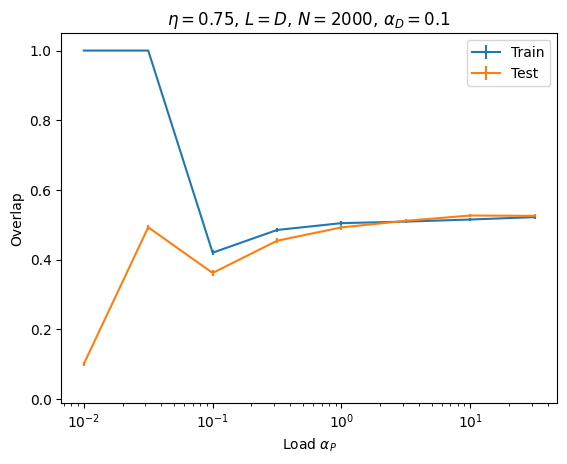

In [7]:
fname = "GAP_PL_curves_eta{}_N{}_alpha_D{}_L_D_epochs{}_varying_alpha_P.npz".format(exponent, N, alpha_D,epochs)
saved_dict = np.load("/home/benedetti/RF_power_law/data/"+fname, allow_pickle=True)

mean_arr_train = saved_dict["means_train"]
std_arr_train = saved_dict["std_train"]
mean_arr_test = saved_dict["means_test"]
std_arr_test = saved_dict["std_test"]
alpha_P_array = saved_dict["alpha_P_arr"]
aD =  saved_dict["alpha_D"]
N =  saved_dict["N"]
eta_value = saved_dict["eta"]
s_arr = saved_dict["seeds_arr"]
len_s_arr = len(s_arr)

means_train = np.empty(len(alpha_P_arr), dtype=object)
std_train = np.empty(len(alpha_P_arr), dtype=object)
means_test = np.empty(len(alpha_P_arr), dtype=object)
std_test = np.empty(len(alpha_P_arr), dtype=object)

for i_a, alpha_P in enumerate(alpha_P_arr):
    D = int(alpha_D*N)
    P = int(alpha_P*N)
    arr_train = np.zeros((len(seeds_arr), P))
    for i_s in range(len(seeds_arr)):
        arr_train[i_s] = mean_arr_train[i_a][i_s]
    means_train[i_a] = arr_train.mean()
    std_train[i_a] = arr_train.std()
    arr_test = np.zeros((len(seeds_arr), P_hat))
    for i_s in range(len(seeds_arr)):
        arr_test[i_s] = mean_arr_test[i_a][i_s]
    means_test[i_a] = arr_test.mean()
    std_test[i_a] = arr_test.std()



fname = "GAP_PL_curves_eta{}_N{}_alpha_D{}_L_D_epochs{}_varying_alpha_P.npz".format(exponent, N, alpha_D,epochs)
saved_dict_mid = np.load("/home/benedetti/RF_power_law/data/"+fname, allow_pickle=True)

plt.errorbar(alpha_P_array, means_train, std_train/math.sqrt(float(len_s_arr)), label="Train")
plt.errorbar(alpha_P_array, means_test, std_test/math.sqrt(float(len(s_arr))), label="Test")

plt.xlabel(r"Load $\alpha_P$")
plt.ylabel("Overlap")
plt.title(rf"$\eta={exponent}$, $L=D$, $N={N}$, $\alpha_D={alpha_D}$")
plt.ylim((-0.01,1.05))
plt.xscale("log")
plt.legend()
plt.show()

In [77]:
fname = "GAP_PL_curves_eta{}_N{}_alpha_D{}_L_D_epochs{}_varying_alpha_P.npz".format(exponent, N, alpha_D,epochs)
saved_dict = np.load("/home/benedetti/RF_power_law/data/"+fname, allow_pickle=True)

mean_arr_train = saved_dict["means_train"]
std_arr_train = saved_dict["std_train"]
mean_arr_test = saved_dict["means_test"]
std_arr_test = saved_dict["std_test"]
alpha_P_array = saved_dict["alpha_P_arr"]
aD =  saved_dict["alpha_D"]
N =  saved_dict["N"]
eta_value = saved_dict["eta"]
s_arr = saved_dict["seeds_arr"]
len_s_arr = len(s_arr)

means_train = np.empty(len(alpha_P_arr), dtype=object)
std_train = np.empty(len(alpha_P_arr), dtype=object)
means_test = np.empty(len(alpha_P_arr), dtype=object)
std_test = np.empty(len(alpha_P_arr), dtype=object)

for i_a, alpha_P in enumerate(alpha_P_arr):
    D = int(alpha_D*N)
    P = int(alpha_P*N)
    arr_train = np.zeros((len(seeds_arr), P))
    for i_s in range(len(seeds_arr)):
        arr_train[i_s] = mean_arr_train[i_a][i_s]
    means_train[i_a] = arr_train.mean()
    std_train[i_a] = arr_train.std()
    arr_test = np.zeros((len(seeds_arr), P_hat))
    for i_s in range(len(seeds_arr)):
        arr_test[i_s] = mean_arr_test[i_a][i_s]
    means_test[i_a] = arr_test.mean()
    std_test[i_a] = arr_test.std()



fname = "GAP_PL_curves_eta{}_N{}_alpha_D{}_L_D_epochs{}_varying_alpha_P.npz".format(exponent, N, alpha_D,epochs)
saved_dict_mid = np.load("/home/benedetti/RF_power_law/data/"+fname, allow_pickle=True)

plt.errorbar(alpha_P_array, means_train, std_train/math.sqrt(float(len_s_arr)), label="Train")
plt.errorbar(alpha_P_array, means_test, std_test/math.sqrt(float(len(s_arr))), label="Test")

plt.xlabel(r"Load $\alpha_P$")
plt.ylabel("Overlap")
plt.title(rf"$\eta={exponent}$, $L=D$, $N={N}$, $\alpha_D={alpha_D}$")
plt.ylim((-0.01,1.05))
plt.xscale("log")
plt.legend()
plt.show()s

SyntaxError: invalid syntax (899606604.py, line 48)

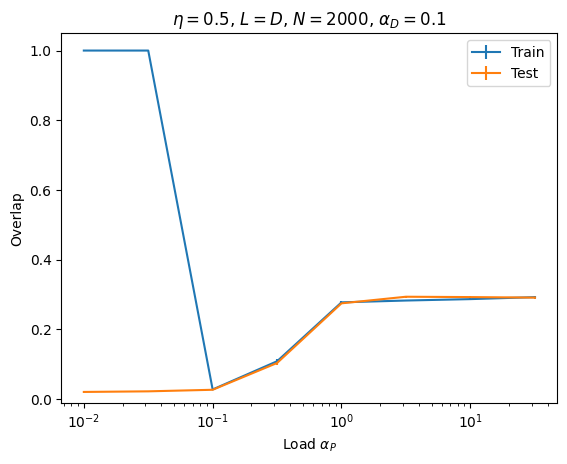

In [51]:
fname = "GAP_PL_curves_eta{}_N{}_alpha_D{}_L_D_epochs{}_varying_alpha_P.npz".format(exponent, N, alpha_D,epochs)
saved_dict = np.load("/home/benedetti/RF_power_law/data/"+fname, allow_pickle=True)

mean_arr_train = saved_dict["means_train"]
std_arr_train = saved_dict["std_train"]
mean_arr_test = saved_dict["means_test"]
std_arr_test = saved_dict["std_test"]
alpha_P_array = saved_dict["alpha_P_arr"]
aD =  saved_dict["alpha_D"]
N =  saved_dict["N"]
eta_value = saved_dict["eta"]
s_arr = saved_dict["seeds_arr"]
len_s_arr = len(s_arr)

means_train = np.empty(len(alpha_P_arr), dtype=object)
std_train = np.empty(len(alpha_P_arr), dtype=object)
means_test = np.empty(len(alpha_P_arr), dtype=object)
std_test = np.empty(len(alpha_P_arr), dtype=object)

for i_a, alpha_P in enumerate(alpha_P_arr):
    D = int(alpha_D*N)
    P = int(alpha_P*N)
    arr_train = np.zeros((len(seeds_arr), P))
    for i_s in range(len(seeds_arr)):
        arr_train[i_s] = mean_arr_train[i_a][i_s]
    means_train[i_a] = arr_train.mean()
    std_train[i_a] = arr_train.std()
    arr_test = np.zeros((len(seeds_arr), P_hat))
    for i_s in range(len(seeds_arr)):
        arr_test[i_s] = mean_arr_test[i_a][i_s]
    means_test[i_a] = arr_test.mean()
    std_test[i_a] = arr_test.std()



fname = "GAP_PL_curves_eta{}_N{}_alpha_D{}_L_D_epochs{}_varying_alpha_P.npz".format(exponent, N, alpha_D,epochs)
saved_dict_mid = np.load("/home/benedetti/RF_power_law/data/"+fname, allow_pickle=True)

plt.errorbar(alpha_P_array, means_train, std_train/math.sqrt(float(len_s_arr)), label="Train")
plt.errorbar(alpha_P_array, means_test, std_test/math.sqrt(float(len(s_arr))), label="Test")

plt.xlabel(r"Load $\alpha_P$")
plt.ylabel("Overlap")
plt.title(rf"$\eta={exponent}$, $L=D$, $N={N}$, $\alpha_D={alpha_D}$")
plt.ylim((-0.01,1.05))
plt.xscale("log")
plt.legend()
plt.show()